In [14]:
import pandas as pd #Loading data
import numpy as np #for mathmematical
import re #regular expressions cleaning data
import nltk #for basics
import matplotlib.pyplot as plt #visualizations
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize#spliting words into unique
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

#download required NLTK files
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [16]:
data = {
    "Review": [
        "The product quality is excellent and delivery was very fast.",
        "Very bad packaging and the item was damaged.",
        "Customer service was helpful and responsive.",
        "The delivery was delayed and support team did not respond.",
        "Amazing product. Worth the money.",
        "Poor quality product and terrible experience.",
        "Fast shipping and good packaging.",
        "The product stopped working after two days.",
        "Excellent service and great quality.",
        "Late delivery and bad customer support."
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

In [17]:
stop_words = set(stopwords.words('english'))
def clean_text(text):
  text=text.lower()
  print('lower case',text)

  text = re.sub(r'[^a-zA-Z\s]','',text)
  print('special character',text)

  words = word_tokenize(text)
  print('tokenization',words)

  #Remove stopwords
  words = [word for word in words if word not in stop_words]
  print('stop words',words)

  # join words again
  cleaned_text = " ".join(words)

  return cleaned_text

# apply cleaning function
df['Cleaned_Review'] = df['Review'].apply(clean_text)

print("\n Cleaned Reviews")
print(df['Cleaned_Review'])








lower case the product quality is excellent and delivery was very fast.
special character the product quality is excellent and delivery was very fast
tokenization ['the', 'product', 'quality', 'is', 'excellent', 'and', 'delivery', 'was', 'very', 'fast']
stop words ['product', 'quality', 'excellent', 'delivery', 'fast']
lower case very bad packaging and the item was damaged.
special character very bad packaging and the item was damaged
tokenization ['very', 'bad', 'packaging', 'and', 'the', 'item', 'was', 'damaged']
stop words ['bad', 'packaging', 'item', 'damaged']
lower case customer service was helpful and responsive.
special character customer service was helpful and responsive
tokenization ['customer', 'service', 'was', 'helpful', 'and', 'responsive']
stop words ['customer', 'service', 'helpful', 'responsive']
lower case the delivery was delayed and support team did not respond.
special character the delivery was delayed and support team did not respond
tokenization ['the', 'delive

# Sentiment Analysis

In [19]:
sia = SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if score['compound'] >= 0.05:
    return 'Positive'
  elif score['compound'] <= -0.05:
    return 'Negative'
  else:
    return 'Neutral'

df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
print("\nSentiment analysis Result")
print(df[['Review','Sentiment']])




Sentiment analysis Result
                                              Review Sentiment
0  The product quality is excellent and delivery ...  Positive
1       Very bad packaging and the item was damaged.  Negative
2       Customer service was helpful and responsive.  Positive
3  The delivery was delayed and support team did ...  Positive
4                  Amazing product. Worth the money.  Positive
5      Poor quality product and terrible experience.  Negative
6                  Fast shipping and good packaging.  Positive
7        The product stopped working after two days.  Negative
8               Excellent service and great quality.  Positive
9            Late delivery and bad customer support.  Negative


# Find Common Keywords

In [23]:
all_words = " ".join(df['Cleaned_Review'])
word_list = all_words.split()

#count word frequency
word_freq = Counter(word_list)

#Display top 10 keywords
print("\nWord Frequency")
print(word_freq.most_common(10))


Word Frequency
[('product', 4), ('quality', 3), ('delivery', 3), ('excellent', 2), ('fast', 2), ('bad', 2), ('packaging', 2), ('customer', 2), ('service', 2), ('support', 2)]


# Step 6 :Identify Common Complaints

In [24]:
negative_reviews = df[df['Sentiment'] == 'Negative']
all_negative_words = " ".join(negative_reviews['Cleaned_Review'])

negative_word_list = all_negative_words.split()
complaint_freq = Counter(negative_word_list)
print("Top 10 common negative keywords \n",complaint_freq.most_common(10))

Top 10 common negative keywords 
 [('bad', 2), ('product', 2), ('packaging', 1), ('item', 1), ('damaged', 1), ('poor', 1), ('quality', 1), ('terrible', 1), ('experience', 1), ('stopped', 1)]


# step 7 :Visualization - Sentiment Count

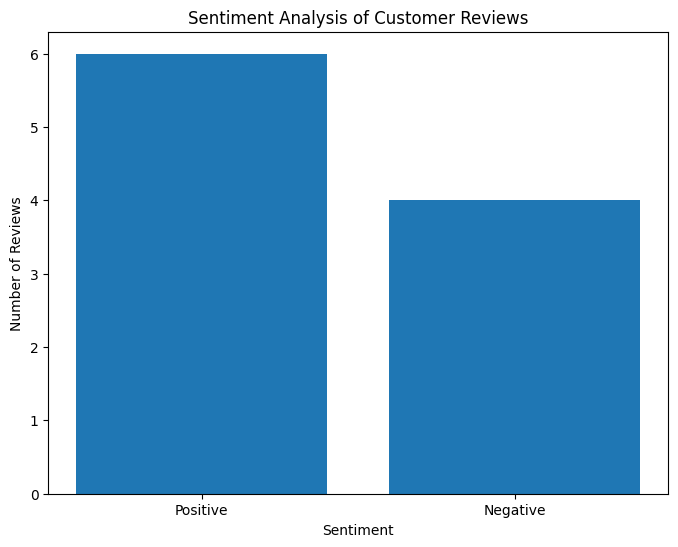

In [25]:

sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.title('Sentiment Analysis of Customer Reviews')
plt.show()

# Step 8:Generate Word Cloud


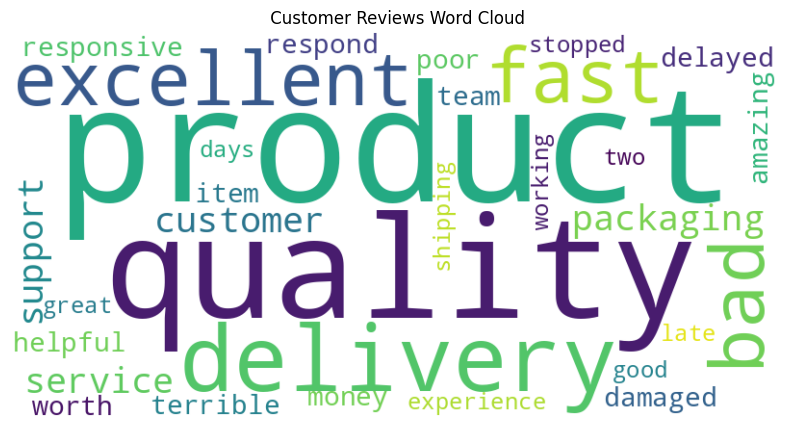

In [27]:
wordcloud = WordCloud(width=800,height=400,background_color='white').generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title(' Customer Reviews Word Cloud')
plt.show()